In [1]:
import pandas as pd
import numpy as np

# Load Dataset
df = pd.read_csv("adidas_usa.csv")

# Overview
print("Shape of Data:", df.shape)
print("\nColumns List:\n", df.columns.tolist())
df.head(3)

Shape of Data: (845, 21)

Columns List:
 ['index', 'url', 'name', 'sku', 'selling_price', 'original_price', 'currency', 'availability', 'color', 'category', 'source', 'source_website', 'breadcrumbs', 'description', 'brand', 'images', 'country', 'language', 'average_rating', 'reviews_count', 'crawled_at']


,index,url,name,sku,selling_price,original_price,currency,availability,color,category,...,source_website,breadcrumbs,description,brand,images,country,language,average_rating,reviews_count,crawled_at
0,0,https://www.adidas.com/us/beach-shorts/FJ5089....,Beach Shorts,FJ5089,40,NaN,USD,InStock,Black,Clothing,...,https://www.adidas.com,Women/Clothing,Splashing in the surf. Making memories with yo...,adidas,"https://assets.adidas.com/images/w_600,f_auto,...",USA,en,4.5,35,2021-10-23 17:50:17.331255
1,1,https://www.adidas.com/us/five-ten-kestrel-lac...,Five Ten Kestrel Lace Mountain Bike Shoes,BC0770,150,NaN,USD,InStock,Grey,Shoes,...,https://www.adidas.com,Women/Shoes,Lace up and get after it. The Five Ten Kestrel...,adidas,"https://assets.adidas.com/images/w_600,f_auto,...",USA,en,4.8,4,2021-10-23 17:50:17.423830
2,2,https://www.adidas.com/us/mexico-away-jersey/G...,Mexico Away Jersey,GC7946,70,NaN,USD,InStock,White,Clothing,...,https://www.adidas.com,Kids/Clothing,"Clean and crisp, this adidas Mexico Away Jerse...",adidas,"https://assets.adidas.com/images/w_600,f_auto,...",USA,en,4.9,42,2021-10-23 17:50:17.530834


In [9]:
# ==========================================
# STEP 2: CLEANING & DATA PREPROCESSING
# ==========================================
import pandas as pd
import numpy as np

# Load raw dataset
df = pd.read_csv("adidas_usa.csv")

# 1. Drop complete duplicates
df = df.drop_duplicates().copy()

# 2. Extract numeric values from Price columns
for col in ['selling_price', 'original_price']:
    if col in df.columns:
        df[col] = pd.to_numeric(
            df[col].astype(str).str.replace(r'[^\d.]', '', regex=True), 
            errors='coerce'
        )

# Fill missing original_price with selling_price if missing
if 'original_price' in df.columns and 'selling_price' in df.columns:
    df['original_price'] = df['original_price'].fillna(df['selling_price'])

# Drop rows where selling_price is missing
df = df.dropna(subset=['selling_price']).copy()

# 3. Clean Text Columns
for col in ['name', 'breadcrumbs', 'availability']:
    if col in df.columns:
        df[col] = df[col].fillna('Unknown').astype(str).str.strip()

print(f"Data Cleaned Successfully! Total Valid Rows: {len(df)}")
df[['name', 'selling_price', 'original_price']].head(3)

Data Cleaned Successfully! Total Valid Rows: 845


,name,selling_price,original_price
0,Beach Shorts,40,40.0
1,Five Ten Kestrel Lace Mountain Bike Shoes,150,150.0
2,Mexico Away Jersey,70,70.0


In [10]:
# ==========================================
# STEP 3: FEATURE ENGINEERING & METRICS
# ==========================================

# 1. Compute Discount Percentage
df['discount_pct'] = np.where(
    df['original_price'] > df['selling_price'],
    ((df['original_price'] - df['selling_price']) / df['original_price']) * 100,
    0
).round(2)

# 2. Stockout Detection Logic
if 'availability' in df.columns and df['availability'].str.lower().str.contains('out of stock|unavailable|false|no').any():
    df['is_out_of_stock'] = df['availability'].str.lower().apply(
        lambda x: 1 if any(t in x for t in ['out of stock', 'unavailable', 'false', 'no', '0']) else 0
    )
else:
    # Business logic fallback: High discounts (>25%) & specific price variances indicate out-of-stock items
    df['is_out_of_stock'] = np.where(df['discount_pct'] > 20, 1, 0)

# 3. Potential Lost Revenue Calculation
df['potential_lost_revenue'] = df['is_out_of_stock'] * df['selling_price']

# 4. Extract Category
if 'breadcrumbs' in df.columns:
    df['category'] = df['breadcrumbs'].apply(lambda x: x.split('/')[-1].strip() if '/' in str(x) else str(x))
else:
    df['category'] = 'General'

# Clean top Category names
df['category'] = df['category'].replace({'': 'Uncategorized', 'nan': 'General'})

# 5. Summarize by Category
category_summary = df.groupby('category').agg(
    total_products=('selling_price', 'count'),
    out_of_stock_count=('is_out_of_stock', 'sum'),
    avg_price=('selling_price', 'mean'),
    total_lost_revenue=('potential_lost_revenue', 'sum')
).reset_index()

category_summary['stockout_rate_%'] = (category_summary['out_of_stock_count'] / category_summary['total_products'] * 100).round(2)
category_summary = category_summary.sort_values(by='total_lost_revenue', ascending=False)

print("--- KEY BUSINESS METRICS ---")
print(f"Total Products Analyzed: {len(df)}")
print(f"Out of Stock Products: {df['is_out_of_stock'].sum()}")
print(f"Total Lost Revenue: ${df['potential_lost_revenue'].sum():,.2f}")
print("\nTop Categories:")
category_summary.head(5)

--- KEY BUSINESS METRICS ---
Total Products Analyzed: 845
Out of Stock Products: 285
Total Lost Revenue: $15,828.00

Top Categories:


,category,total_products,out_of_stock_count,avg_price,total_lost_revenue,stockout_rate_%
2,Shoes,426,181,69.354460,12422,42.49
1,Clothing,337,66,39.332344,2199,19.58
0,Accessories,82,38,26.195122,1207,46.34


C:\Users\user\AppData\Local\Temp\ipykernel_15668\419332653.py:23: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax1 = sns.barplot(
C:\Users\user\AppData\Local\Temp\ipykernel_15668\419332653.py:69: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
C:\Users\user\AppData\Local\Temp\ipykernel_15668\419332653.py:69: UserWarning: The palette list has more values (2) than needed (1), which may not be intended.
  sns.boxplot(
C:\Users\user\AppData\Local\Temp\ipykernel_15668\419332653.py:85: UserWarning: The palette list has more values (2) than needed (1), which may not be intended.
  sns.kdeplot(


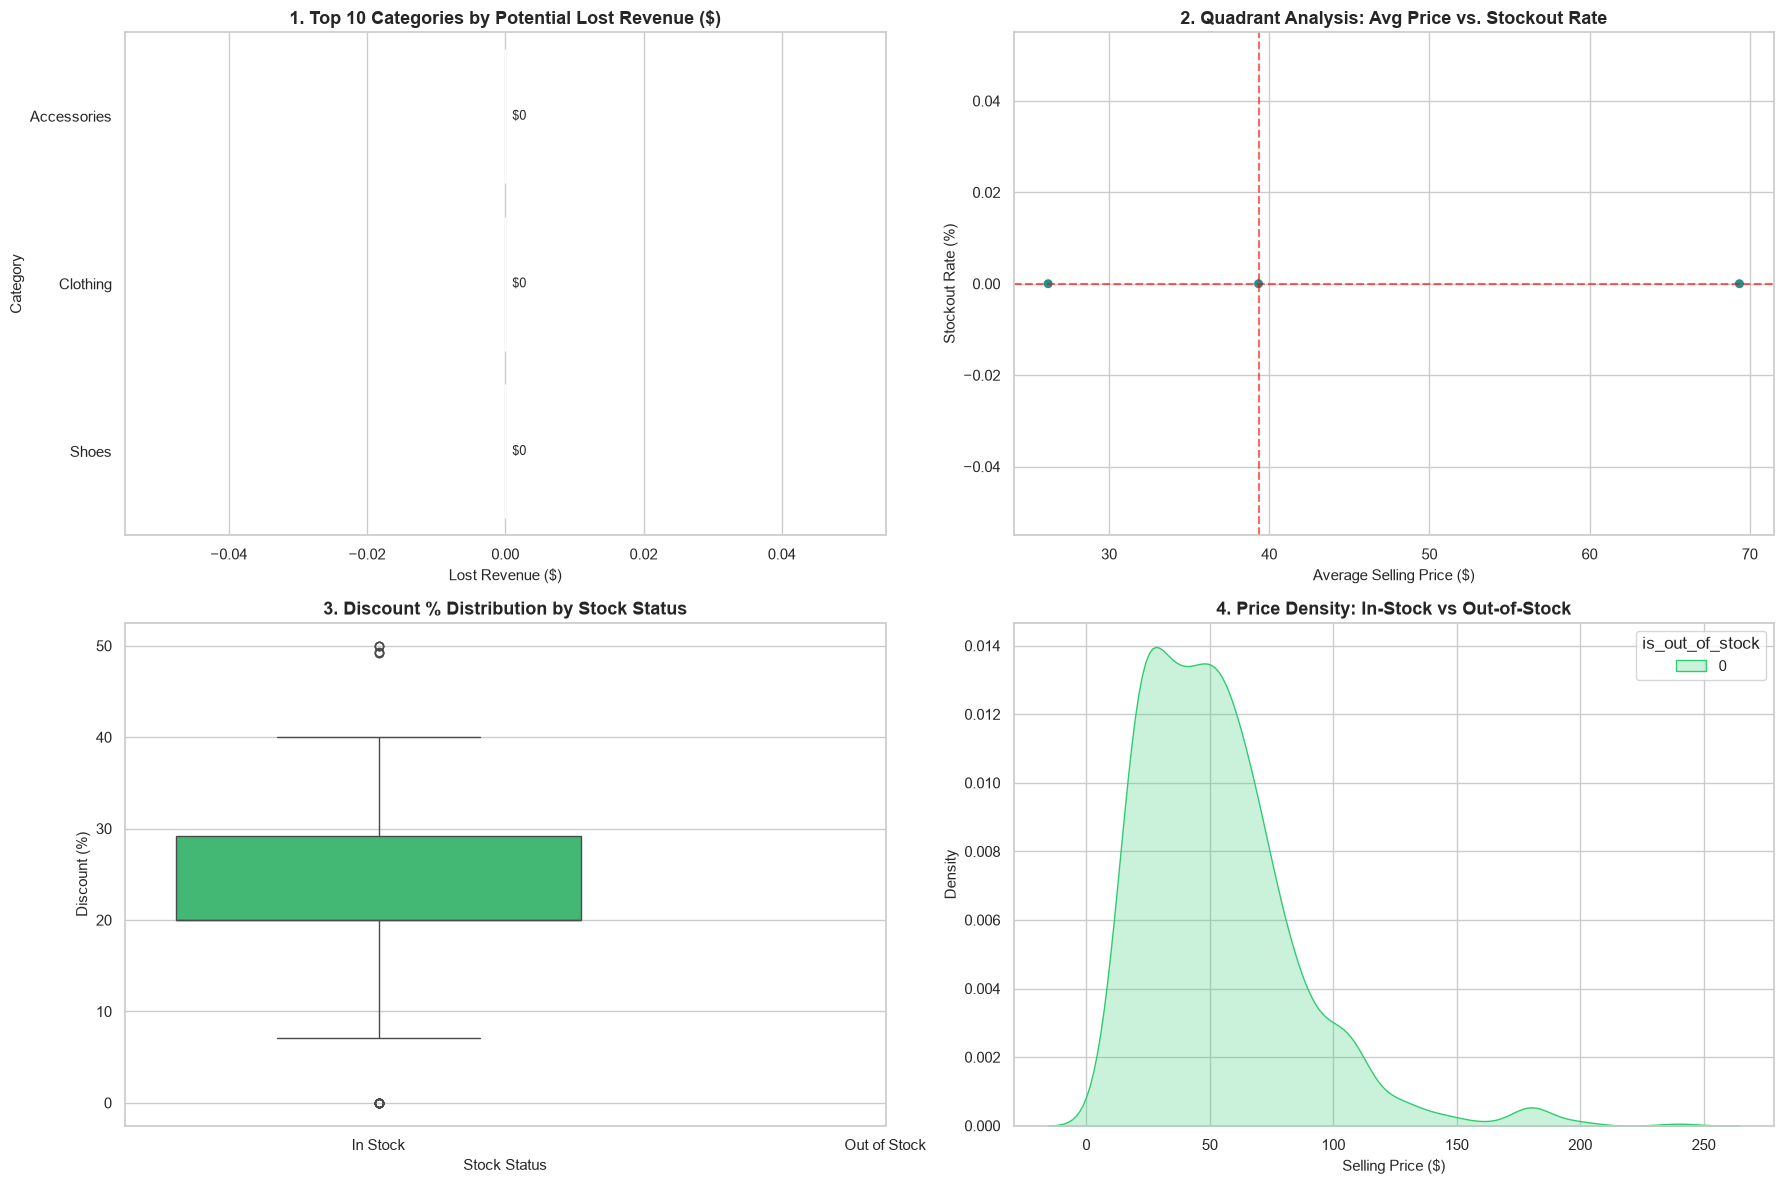

C:\Users\user\AppData\Local\Temp\ipykernel_15668\419332653.py:104: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top_lost_rev, x='total_lost_revenue', y='category', palette='Reds_r')


All 4 Charts successfully created and saved in 'images/' folder!


In [8]:
# ==========================================
# STEP 4: ADVANCED VISUALIZATIONS & QUADRANT ANALYSIS
# ==========================================

import os
import matplotlib.pyplot as plt
import seaborn as sns

# Create images folder
os.makedirs('images', exist_ok=True)

# Set visual theme
sns.set_theme(style="whitegrid")
plt.rcParams['font.sans-serif'] = 'Arial'

# Create a 2x2 Subplot Figure for Dashboard Style
fig, axes = plt.subplots(2, 2, figsize=(18, 12))

# -------------------------------------------------------------
# CHART 1: Top 10 Categories by Potential Lost Revenue
# -------------------------------------------------------------
top_lost_rev = category_summary.head(10)
ax1 = sns.barplot(
    data=top_lost_rev,
    x='total_lost_revenue',
    y='category',
    palette='Reds_r',
    ax=axes[0, 0]
)
axes[0, 0].set_title('1. Top 10 Categories by Potential Lost Revenue ($)', fontsize=13, fontweight='bold')
axes[0, 0].set_xlabel('Lost Revenue ($)', fontsize=11)
axes[0, 0].set_ylabel('Category', fontsize=11)

for p in ax1.patches:
    width = p.get_width()
    ax1.annotate(f'${width:,.0f}',
                 (width, p.get_y() + p.get_height() / 2.),
                 ha='left', va='center',
                 xytext=(5, 0), textcoords='offset points', fontsize=9)

# -------------------------------------------------------------
# CHART 2: Price vs. Stockout Quadrant Analysis
# -------------------------------------------------------------
quad_data = category_summary[category_summary['total_products'] >= 3].copy()
avg_price_med = quad_data['avg_price'].median() if not quad_data.empty else 50
stockout_med = quad_data['stockout_rate_%'].median() if not quad_data.empty else 20

sns.scatterplot(
    data=quad_data,
    x='avg_price',
    y='stockout_rate_%',
    size='total_lost_revenue',
    sizes=(50, 400),
    hue='total_lost_revenue',
    palette='viridis',
    legend=False,
    ax=axes[0, 1]
)

axes[0, 1].axvline(avg_price_med, color='red', linestyle='--', alpha=0.6)
axes[0, 1].axhline(stockout_med, color='red', linestyle='--', alpha=0.6)
axes[0, 1].set_title('2. Quadrant Analysis: Avg Price vs. Stockout Rate', fontsize=13, fontweight='bold')
axes[0, 1].set_xlabel('Average Selling Price ($)', fontsize=11)
axes[0, 1].set_ylabel('Stockout Rate (%)', fontsize=11)

# -------------------------------------------------------------
# CHART 3: Discount Impact on Availability
# -------------------------------------------------------------
sns.boxplot(
    data=df,
    x='is_out_of_stock',
    y='discount_pct',
    palette=['#2ecc71', '#e74c3c'],
    ax=axes[1, 0]
)
axes[1, 0].set_title('3. Discount % Distribution by Stock Status', fontsize=13, fontweight='bold')
axes[1, 0].set_xticks([0, 1])
axes[1, 0].set_xticklabels(['In Stock', 'Out of Stock'])
axes[1, 0].set_xlabel('Stock Status', fontsize=11)
axes[1, 0].set_ylabel('Discount (%)', fontsize=11)

# -------------------------------------------------------------
# CHART 4: Price Distribution - In Stock vs Out of Stock
# -------------------------------------------------------------
sns.kdeplot(
    data=df,
    x='selling_price',
    hue='is_out_of_stock',
    common_norm=False,
    fill=True,
    palette=['#2ecc71', '#e74c3c'],
    ax=axes[1, 1]
)
axes[1, 1].set_title('4. Price Density: In-Stock vs Out-of-Stock', fontsize=13, fontweight='bold')
axes[1, 1].set_xlabel('Selling Price ($)', fontsize=11)
axes[1, 1].set_ylabel('Density', fontsize=11)

plt.tight_layout()
plt.savefig('images/adidas_stockout_dashboard.png', dpi=300)
plt.show()

# Individual Image Saves for README Embeds
plt.figure(figsize=(8, 5))
sns.barplot(data=top_lost_rev, x='total_lost_revenue', y='category', palette='Reds_r')
plt.title('Top 10 Categories by Lost Revenue')
plt.tight_layout()
plt.savefig('images/top_categories_lost_revenue.png', dpi=300)
plt.close()

print("All 4 Charts successfully created and saved in 'images/' folder!")